# Part C: Warehouse Assignment Optimization

This notebook builds a simplified warehouse assignment model for JD.com order lines. The goal is to reassign each sampled order line to one feasible candidate warehouse in the destination-region network group and compare the optimized assignment against the observed historical assignment.

Part C reuses the processed Part A tables and the Analysis 3 fulfillment-time proxy. It does not rebuild the earlier descriptive analysis.

## 2. Optimization problem framing

We solve a single-period assignment problem on a manageable sample of order lines.

Sets:
- I: sampled order lines
- J(i): feasible candidate warehouses for order line i, already restricted to the destination region candidate set

Parameters:
- a_ij = 1 if candidate warehouse j has binary end-of-day inventory available for order line i
- r_ij = 1 if candidate warehouse j is remote relative to dc_des
- t_hat_ij = predicted fulfillment hours from the Analysis 3 proxy model
- lambda_remote = scalar penalty on remote fulfillment

Decision variable:
- x_ij in {0, 1} equals 1 if order line i is assigned to candidate warehouse j

Objective:
Minimize the sum of predicted fulfillment hours plus a remote-assignment penalty.

Constraints:
1. Each order line is assigned exactly once
2. Inventory feasibility: x_ij <= a_ij
3. Candidate-region feasibility is enforced upstream through the processed candidate table

Base model choice:
- no capacity constraint in the base specification
- no multi-period inventory planning
- no package-routing detail beyond the order-level delivery summary already built in Part A

## 3. Load processed inputs

In [1]:
%matplotlib inline

from pathlib import Path
import inspect

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pulp

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

ORDER_LINE_PATH = PROCESSED_DIR / "order_line_with_inventory.csv"
CANDIDATE_PATH = PROCESSED_DIR / "assignment_candidates.csv"

SCORED_CANDIDATE_PATHS = [
    PROCESSED_DIR / "assignment_candidates_scored.csv",
    PROCESSED_DIR / "assignment_candidates_with_predictions.csv",
    PROCESSED_DIR / "candidate_scoring_output.csv",
]

order_usecols = [
    "order_line_id",
    "order_date",
    "dc_des",
    "dc_ori",
    "hours_to_delivery",
    "delivered_by_jd_flag",
    "promise_days",
    "promise",
    "quantity",
    "discount_rate",
    "package_count",
    "inventory_at_dc_ori",
    "num_available_dcs_in_region",
    "plus",
    "user_level",
    "purchase_power",
    "city_level",
    "destination_region_id",
    "type",
]

candidate_usecols = [
    "order_line_id",
    "order_id",
    "sku_id",
    "user_id",
    "order_date",
    "dc_des",
    "dc_ori",
    "destination_region_id",
    "candidate_dc",
    "candidate_in_destination_region_flag",
    "candidate_remote_flag",
    "inventory_available",
]

order_line_df = pd.read_csv(ORDER_LINE_PATH, low_memory=False, usecols=lambda c: c in order_usecols)
candidate_df = pd.read_csv(CANDIDATE_PATH, low_memory=False, usecols=lambda c: c in candidate_usecols)

existing_scored_path = next((path for path in SCORED_CANDIDATE_PATHS if path.exists()), None)
scored_candidate_df = pd.read_csv(existing_scored_path, low_memory=False) if existing_scored_path else None

print(f"order_line_with_inventory rows: {len(order_line_df):,}")
print(f"assignment_candidates rows: {len(candidate_df):,}")
print(f"Scored candidate file found: {existing_scored_path}")

order_line_with_inventory rows: 549,989
assignment_candidates rows: 3,809,107
Scored candidate file found: None


## 4. Inspect candidate assignment data

In [2]:
for frame in [order_line_df, candidate_df]:
    for col in ["order_line_id", "dc_des", "dc_ori", "destination_region_id"]:
        if col in frame.columns:
            frame[col] = frame[col].astype("string")
    if "candidate_dc" in frame.columns:
        frame["candidate_dc"] = frame["candidate_dc"].astype("string")
    if "order_date" in frame.columns:
        frame["order_date"] = pd.to_datetime(frame["order_date"], errors="coerce").dt.normalize()

for col in ["candidate_in_destination_region_flag", "candidate_remote_flag", "inventory_available"]:
    if col in candidate_df.columns:
        candidate_df[col] = pd.to_numeric(candidate_df[col], errors="coerce").fillna(0).astype(int)

candidate_summary = pd.DataFrame(
    {
        "metric": [
            "candidate_rows",
            "unique_order_lines",
            "avg_candidates_per_order_line",
            "share_in_destination_region_flag_eq_1",
            "share_inventory_available_eq_1",
            "share_remote_candidates",
        ],
        "value": [
            len(candidate_df),
            candidate_df["order_line_id"].nunique(),
            len(candidate_df) / candidate_df["order_line_id"].nunique(),
            candidate_df["candidate_in_destination_region_flag"].mean(),
            candidate_df["inventory_available"].mean(),
            candidate_df["candidate_remote_flag"].mean(),
        ],
    }
)

display(candidate_summary)
display(candidate_df.head())

,metric,value
0,candidate_rows,3.809107e+06
1,unique_order_lines,5.499890e+05
2,avg_candidates_per_order_line,6.925788e+00
3,share_in_destination_region_flag_eq_1,1.000000e+00
4,share_inventory_available_eq_1,2.722231e-01
5,share_remote_candidates,8.556121e-01


,order_line_id,order_id,sku_id,user_id,order_date,dc_des,dc_ori,destination_region_id,candidate_dc,candidate_in_destination_region_flag,candidate_remote_flag,inventory_available
0,0000095025_ecc00df0b6_0,0000095025,ecc00df0b6,57648ed1fc,2018-03-19,2,2,2.0,2.0,1,0,1
1,0000095025_ecc00df0b6_0,0000095025,ecc00df0b6,57648ed1fc,2018-03-19,2,2,2.0,6.0,1,1,0
2,0000095025_ecc00df0b6_0,0000095025,ecc00df0b6,57648ed1fc,2018-03-19,2,2,2.0,15.0,1,1,0
3,0000095025_ecc00df0b6_0,0000095025,ecc00df0b6,57648ed1fc,2018-03-19,2,2,2.0,20.0,1,1,0
4,0000095025_ecc00df0b6_0,0000095025,ecc00df0b6,57648ed1fc,2018-03-19,2,2,2.0,42.0,1,1,0


## 5. Build optimization input tables

We keep the optimization notebook-friendly by solving a transparent sample:
- first 7 observed order dates in the processed order-line table
- top 3 destination DCs by order-line count within those dates
- at most 1,500 order lines after sorting by date and order line ID

For baseline-vs-optimized comparison, we do not require every historical dc_ori to appear inside the destination-region candidate set. Instead, the baseline is defined as:
1. use the historical dc_ori if it is present among feasible candidates
2. otherwise use a simple current-candidate baseline inside the feasible set: prefer dc_des when available, then break ties by candidate_dc

This keeps the comparison feasible while respecting the assignment-candidate construction.

In [3]:
def stable_holdout_mask(series: pd.Series, train_share: float = 0.8) -> pd.Series:
    hashed = pd.util.hash_pandas_object(series.astype("string"), index=False).astype("uint64")
    return (hashed % 10) < int(train_share * 10)


def make_onehot_encoder():
    params = inspect.signature(OneHotEncoder).parameters
    if "sparse_output" in params:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_modeling_sample(df: pd.DataFrame) -> pd.DataFrame:
    out = pd.DataFrame(
        {
            "order_line_id": df["order_line_id"].astype("string"),
            "hours_to_delivery": pd.to_numeric(df.get("hours_to_delivery"), errors="coerce"),
            "remote_fulfillment_flag": (df["dc_ori"].astype("string") != df["dc_des"].astype("string")).astype(float),
            "promise_days": pd.to_numeric(df.get("promise_days", df.get("promise")), errors="coerce"),
            "quantity": pd.to_numeric(df.get("quantity"), errors="coerce"),
            "discount_rate": pd.to_numeric(df.get("discount_rate"), errors="coerce"),
            "package_count": pd.to_numeric(df.get("package_count"), errors="coerce"),
            "inventory_at_fulfillment_dc": pd.to_numeric(df.get("inventory_at_dc_ori"), errors="coerce"),
            "num_available_dcs_in_region": pd.to_numeric(df.get("num_available_dcs_in_region"), errors="coerce"),
            "plus": pd.to_numeric(df.get("plus"), errors="coerce"),
            "user_level": pd.to_numeric(df.get("user_level"), errors="coerce"),
            "purchase_power": pd.to_numeric(df.get("purchase_power"), errors="coerce"),
            "city_level": pd.to_numeric(df.get("city_level"), errors="coerce"),
            "destination_region_id": df.get("destination_region_id").astype("string") if "destination_region_id" in df.columns else pd.Series(pd.NA, index=df.index, dtype="string"),
            "delivered_by_jd_flag": pd.to_numeric(df.get("delivered_by_jd_flag"), errors="coerce") if "delivered_by_jd_flag" in df.columns else 1,
        }
    )

    sku_type_raw = df.get("type")
    if sku_type_raw is None:
        out["sku_type"] = "Unknown"
    else:
        sku_type_num = pd.to_numeric(sku_type_raw, errors="coerce")
        sku_type_text = sku_type_raw.astype("string").fillna("Unknown").str.upper()
        out["sku_type"] = "Unknown"
        out.loc[sku_type_num.eq(1).fillna(False), "sku_type"] = "1P"
        out.loc[sku_type_num.eq(2).fillna(False), "sku_type"] = "3P"
        valid_text_mask = sku_type_text.isin(["1P", "3P"]).fillna(False)
        out.loc[valid_text_mask, "sku_type"] = sku_type_text.loc[valid_text_mask]

    out = out.loc[out["delivered_by_jd_flag"].fillna(1).eq(1)].copy()
    out = out.loc[out["hours_to_delivery"].notna()].copy()
    out = out.loc[out["hours_to_delivery"] > 0].copy()
    out = out.loc[out["hours_to_delivery"] <= 240].copy()

    out["promise_missing_flag"] = out["promise_days"].isna().astype(int)
    out["package_missing_flag"] = out["package_count"].isna().astype(int)
    out["log_hours_to_delivery"] = np.log1p(out["hours_to_delivery"])
    return out.reset_index(drop=True)


def add_business_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["sku_type_3p_flag"] = (out["sku_type"] == "3P").astype(float)
    out["remote_x_inventory_at_fulfillment_dc"] = out["remote_fulfillment_flag"] * out["inventory_at_fulfillment_dc"]
    out["remote_x_package_count"] = out["remote_fulfillment_flag"] * out["package_count"]
    out["remote_x_promise_days"] = out["remote_fulfillment_flag"] * out["promise_days"]
    out["remote_x_sku_type_3p"] = out["remote_fulfillment_flag"] * out["sku_type_3p_flag"]
    return out


def prepare_model_matrix(df: pd.DataFrame, numeric_features: list[str], categorical_features: list[str]) -> pd.DataFrame:
    out = df.copy().replace({pd.NA: np.nan})
    for col in numeric_features:
        out[col] = pd.to_numeric(out[col], errors="coerce")
    for col in categorical_features:
        out[col] = out[col].astype("object")
        out[col] = out[col].where(pd.notna(out[col]), np.nan)
    return out


def fit_analysis3_proxy(order_line_raw: pd.DataFrame):
    model_df = add_business_features(build_modeling_sample(order_line_raw))
    train_mask = stable_holdout_mask(model_df["order_line_id"])

    numeric_features = [
        "remote_fulfillment_flag",
        "promise_days",
        "promise_missing_flag",
        "quantity",
        "discount_rate",
        "package_count",
        "package_missing_flag",
        "inventory_at_fulfillment_dc",
        "num_available_dcs_in_region",
        "plus",
        "user_level",
        "purchase_power",
        "city_level",
        "remote_x_inventory_at_fulfillment_dc",
        "remote_x_package_count",
        "remote_x_promise_days",
        "remote_x_sku_type_3p",
    ]
    categorical_features = ["sku_type", "destination_region_id"]
    feature_columns = numeric_features + categorical_features

    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_onehot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("ridge", RidgeCV(alphas=np.logspace(-2, 2, 10), cv=5)),
        ]
    )

    X_train = prepare_model_matrix(model_df.loc[train_mask, feature_columns].copy(), numeric_features, categorical_features)
    y_train = model_df.loc[train_mask, "log_hours_to_delivery"].copy()
    pipeline.fit(X_train, y_train)
    return model_df, pipeline, feature_columns, numeric_features, categorical_features


def build_candidate_feature_frame(candidate_rows: pd.DataFrame, model_ready_order_line_df: pd.DataFrame) -> pd.DataFrame:
    static_cols = [
        "order_line_id",
        "quantity",
        "discount_rate",
        "promise_days",
        "plus",
        "user_level",
        "purchase_power",
        "city_level",
        "destination_region_id",
        "num_available_dcs_in_region",
        "package_count",
        "sku_type",
    ]
    static_lookup = model_ready_order_line_df[static_cols].drop_duplicates(subset=["order_line_id"]).copy()
    work = candidate_rows.copy().merge(static_lookup, how="left", on="order_line_id", validate="m:1", suffixes=("", "_hist"))

    if "destination_region_id_hist" in work.columns:
        work["destination_region_id"] = work["destination_region_id"].fillna(work["destination_region_id_hist"])

    work["remote_fulfillment_flag"] = pd.to_numeric(work["candidate_remote_flag"], errors="coerce")
    work["inventory_at_fulfillment_dc"] = pd.to_numeric(work["inventory_available"], errors="coerce")
    work["promise_missing_flag"] = pd.to_numeric(work["promise_days"], errors="coerce").isna().astype(int)
    work["package_missing_flag"] = pd.to_numeric(work["package_count"], errors="coerce").isna().astype(int)
    return add_business_features(work)


def ensure_candidate_scores(candidate_rows: pd.DataFrame, order_line_raw: pd.DataFrame, scored_candidates: pd.DataFrame | None = None) -> pd.DataFrame:
    prediction_candidates = [
        "predicted_hours_to_delivery",
        "predicted_delivery_hours",
        "predicted_hours",
        "t_hat_ij",
    ]
    existing_pred_col = next((col for col in prediction_candidates if col in candidate_rows.columns), None)
    if existing_pred_col is not None:
        scored = candidate_rows.copy()
        if existing_pred_col != "predicted_hours_to_delivery":
            scored = scored.rename(columns={existing_pred_col: "predicted_hours_to_delivery"})
        return scored

    if scored_candidates is not None:
        scored_copy = scored_candidates.copy()
        pred_col = next((col for col in prediction_candidates if col in scored_copy.columns), None)
        if pred_col is not None:
            if pred_col != "predicted_hours_to_delivery":
                scored_copy = scored_copy.rename(columns={pred_col: "predicted_hours_to_delivery"})
            join_cols = [col for col in ["order_line_id", "candidate_dc", "predicted_hours_to_delivery"] if col in scored_copy.columns]
            merged = candidate_rows.merge(
                scored_copy[join_cols].drop_duplicates(subset=["order_line_id", "candidate_dc"]),
                how="left",
                on=["order_line_id", "candidate_dc"],
                validate="m:1",
            )
            if merged["predicted_hours_to_delivery"].notna().all():
                return merged

    model_ready_order_line_df, fitted_pipeline, feature_columns, numeric_features, categorical_features = fit_analysis3_proxy(order_line_raw)
    work = build_candidate_feature_frame(candidate_rows=candidate_rows, model_ready_order_line_df=model_ready_order_line_df)
    work["package_count"] = work["package_count"].fillna(model_ready_order_line_df["package_count"].median())
    model_input = prepare_model_matrix(work[feature_columns].copy(), numeric_features, categorical_features)
    pred_log = fitted_pipeline.predict(model_input)
    work["predicted_hours_to_delivery"] = np.clip(np.expm1(pred_log), a_min=0, a_max=None)
    return work


def build_baseline_assignments(candidate_input: pd.DataFrame) -> pd.DataFrame:
    baseline = candidate_input.copy()
    baseline["historical_feasible_flag"] = (baseline["candidate_dc"].astype("string") == baseline["dc_ori"].astype("string")).astype(int)
    baseline["destination_match_flag"] = (baseline["candidate_dc"].astype("string") == baseline["dc_des"].astype("string")).astype(int)
    baseline["baseline_rank"] = np.where(
        baseline["historical_feasible_flag"].eq(1),
        0,
        np.where(baseline["destination_match_flag"].eq(1), 1, 2),
    )
    baseline = baseline.sort_values(
        ["order_line_id", "baseline_rank", "predicted_hours_to_delivery", "candidate_dc"],
        ascending=[True, True, True, True],
    )
    baseline = baseline.drop_duplicates(subset=["order_line_id"], keep="first").copy()
    baseline["baseline_type"] = np.select(
        [baseline["historical_feasible_flag"].eq(1), baseline["destination_match_flag"].eq(1)],
        ["historical_if_feasible", "destination_dc_fallback"],
        default="candidate_set_fallback",
    )
    return baseline


sample_dates = sorted(order_line_df["order_date"].dropna().unique())[:7]
date_filtered_lines = order_line_df.loc[order_line_df["order_date"].isin(sample_dates)].copy()
top_destination_dcs = (
    date_filtered_lines["dc_des"]
    .astype("string")
    .value_counts()
    .head(3)
    .index
    .tolist()
)

sample_lines = (
    date_filtered_lines.loc[date_filtered_lines["dc_des"].isin(top_destination_dcs)]
    .sort_values(["order_date", "order_line_id"])
    .drop_duplicates(subset=["order_line_id"])
    .head(1500)
    .copy()
)

if sample_lines.empty:
    sample_lines = order_line_df.sort_values(["order_date", "order_line_id"]).drop_duplicates(subset=["order_line_id"]).head(1500).copy()
    top_destination_dcs = sample_lines["dc_des"].astype("string").value_counts().head(3).index.tolist()
    sample_dates = sorted(sample_lines["order_date"].dropna().unique())

scored_candidate_full = ensure_candidate_scores(candidate_df.copy(), order_line_df, scored_candidate_df)

required_candidate_cols = [
    "order_line_id",
    "candidate_dc",
    "inventory_available",
    "candidate_remote_flag",
    "predicted_hours_to_delivery",
]
missing_candidate_cols = [col for col in required_candidate_cols if col not in scored_candidate_full.columns]
if missing_candidate_cols:
    raise ValueError(f"Candidate input is missing required optimization columns: {missing_candidate_cols}")

scored_candidate_full["predicted_hours_to_delivery"] = pd.to_numeric(scored_candidate_full["predicted_hours_to_delivery"], errors="coerce")
feasible_candidate_full = scored_candidate_full.loc[scored_candidate_full["inventory_available"].eq(1)].copy()
feasible_candidate_full = feasible_candidate_full.loc[feasible_candidate_full["predicted_hours_to_delivery"].notna()].copy()

candidate_sample = feasible_candidate_full.loc[feasible_candidate_full["order_line_id"].isin(sample_lines["order_line_id"])].copy()
sample_lines = sample_lines.merge(
    candidate_sample[["order_line_id"]].drop_duplicates().assign(any_feasible_candidate=1),
    how="left",
    on="order_line_id",
)
sample_lines["any_feasible_candidate"] = sample_lines["any_feasible_candidate"].fillna(0).astype(int)

eligible_order_line_ids = sample_lines.loc[sample_lines["any_feasible_candidate"].eq(1), "order_line_id"].unique()
optimization_input = candidate_sample.loc[candidate_sample["order_line_id"].isin(eligible_order_line_ids)].copy()
optimization_input = optimization_input.sort_values(["order_line_id", "candidate_dc"]).reset_index(drop=True)
sample_lines_eligible = sample_lines.loc[sample_lines["order_line_id"].isin(eligible_order_line_ids)].copy()

eligible_count = sample_lines_eligible["order_line_id"].nunique()
avg_candidates = len(optimization_input) / eligible_count if eligible_count > 0 else np.nan
baseline_preview = build_baseline_assignments(optimization_input)

input_summary = pd.DataFrame(
    {
        "metric": [
            "sample_dates",
            "top_destination_dcs",
            "sampled_order_lines_before_feasibility_filter",
            "sampled_order_lines_with_any_feasible_candidate",
            "order_lines_used_in_optimization",
            "feasible_candidate_rows_for_optimization",
            "avg_feasible_candidates_per_order_line",
            "baseline_historical_if_feasible_share",
        ],
        "value": [
            ", ".join(pd.Series(sample_dates).astype("string")),
            ", ".join(top_destination_dcs),
            sample_lines["order_line_id"].nunique(),
            sample_lines.loc[sample_lines["any_feasible_candidate"].eq(1), "order_line_id"].nunique(),
            eligible_count,
            len(optimization_input),
            avg_candidates,
            baseline_preview["historical_feasible_flag"].mean() if len(baseline_preview) > 0 else np.nan,
        ],
    }
)

display(input_summary)
display(optimization_input.head())
display(baseline_preview[["order_line_id", "candidate_dc", "baseline_type", "predicted_hours_to_delivery"]].head())

,metric,value
0,sample_dates,"2018-03-01, 2018-03-02, 2018-03-03, 2018-03-04..."
1,top_destination_dcs,"5, 9, 4"
2,sampled_order_lines_before_feasibility_filter,1500
3,sampled_order_lines_with_any_feasible_candidate,1078
4,order_lines_used_in_optimization,1078
5,feasible_candidate_rows_for_optimization,3906
6,avg_feasible_candidates_per_order_line,3.623377
7,baseline_historical_if_feasible_share,0.0


,order_line_id,order_id,sku_id,user_id,order_date,dc_des,dc_ori,destination_region_id,candidate_dc,candidate_in_destination_region_flag,candidate_remote_flag,inventory_available,quantity,discount_rate,promise_days,plus,user_level,purchase_power,city_level,destination_region_id_hist,num_available_dcs_in_region,package_count,sku_type,remote_fulfillment_flag,inventory_at_fulfillment_dc,promise_missing_flag,package_missing_flag,sku_type_3p_flag,remote_x_inventory_at_fulfillment_dc,remote_x_package_count,remote_x_promise_days,remote_x_sku_type_3p,predicted_hours_to_delivery
0,001411762b_9e452b5aee_0,001411762b,9e452b5aee,28e5777554,2018-03-01,4,4,4.0,19.0,1,1,1,1.0,0.2625,1.0,0.0,4.0,2.0,2.0,4.0,5.0,1.0,1P,1,1,0,0,0.0,1,1.0,1.0,0.0,22.618066
1,001411762b_9e452b5aee_0,001411762b,9e452b5aee,28e5777554,2018-03-01,4,4,4.0,28.0,1,1,1,1.0,0.2625,1.0,0.0,4.0,2.0,2.0,4.0,5.0,1.0,1P,1,1,0,0,0.0,1,1.0,1.0,0.0,22.618066
2,001411762b_9e452b5aee_0,001411762b,9e452b5aee,28e5777554,2018-03-01,4,4,4.0,4.0,1,0,1,1.0,0.2625,1.0,0.0,4.0,2.0,2.0,4.0,5.0,1.0,1P,0,1,0,0,0.0,0,0.0,0.0,0.0,19.377280
3,001411762b_9e452b5aee_0,001411762b,9e452b5aee,28e5777554,2018-03-01,4,4,4.0,44.0,1,1,1,1.0,0.2625,1.0,0.0,4.0,2.0,2.0,4.0,5.0,1.0,1P,1,1,0,0,0.0,1,1.0,1.0,0.0,22.618066
4,001411762b_9e452b5aee_0,001411762b,9e452b5aee,28e5777554,2018-03-01,4,4,4.0,45.0,1,1,1,1.0,0.2625,1.0,0.0,4.0,2.0,2.0,4.0,5.0,1.0,1P,1,1,0,0,0.0,1,1.0,1.0,0.0,22.618066


,order_line_id,candidate_dc,baseline_type,predicted_hours_to_delivery
2,001411762b_9e452b5aee_0,4.0,candidate_set_fallback,19.377280
8,001f0aef29_589c2b865b_0,4.0,candidate_set_fallback,20.188478
11,0020fefefc_904fbf8b97_0,5.0,candidate_set_fallback,19.362820
14,002149e275_623d0a582a_0,4.0,candidate_set_fallback,29.962031
18,002e994572_2523d051fd_0,4.0,candidate_set_fallback,51.097387


## 6. Define sets, parameters, and decision variables

In [4]:
BASE_LAMBDA_REMOTE = 5.0

I = optimization_input["order_line_id"].drop_duplicates().tolist()
J_by_i = optimization_input.groupby("order_line_id")["candidate_dc"].apply(list).to_dict()
decision_pairs = list(optimization_input[["order_line_id", "candidate_dc"]].itertuples(index=False, name=None))

a = optimization_input.set_index(["order_line_id", "candidate_dc"])["inventory_available"].astype(int).to_dict()
r = optimization_input.set_index(["order_line_id", "candidate_dc"])["candidate_remote_flag"].astype(int).to_dict()
t_hat = optimization_input.set_index(["order_line_id", "candidate_dc"])["predicted_hours_to_delivery"].astype(float).to_dict()

set_parameter_summary = pd.DataFrame(
    {
        "item": [
            "number_of_order_lines",
            "number_of_candidate_pairs",
            "mean_candidates_per_order_line",
            "min_candidates_per_order_line",
            "max_candidates_per_order_line",
            "lambda_remote",
        ],
        "value": [
            len(I),
            len(decision_pairs),
            np.mean([len(v) for v in J_by_i.values()]),
            np.min([len(v) for v in J_by_i.values()]),
            np.max([len(v) for v in J_by_i.values()]),
            BASE_LAMBDA_REMOTE,
        ],
    }
)

display(set_parameter_summary)
decision_pairs[:5]

,item,value
0,number_of_order_lines,1078.000000
1,number_of_candidate_pairs,3906.000000
2,mean_candidates_per_order_line,3.623377
3,min_candidates_per_order_line,1.000000
4,max_candidates_per_order_line,7.000000
5,lambda_remote,5.000000


[('001411762b_9e452b5aee_0', '19.0'),
 ('001411762b_9e452b5aee_0', '28.0'),
 ('001411762b_9e452b5aee_0', '4.0'),
 ('001411762b_9e452b5aee_0', '44.0'),
 ('001411762b_9e452b5aee_0', '45.0')]

## 7. Build the PuLP model

The base model includes the exact-once assignment constraint and the inventory-feasibility constraint. A capacity-like proxy can be added later as an extension, but it is intentionally omitted from the base specification.

In [5]:
def solve_assignment_model(candidate_input: pd.DataFrame, lambda_remote: float = 5.0, capacity_proxy: pd.DataFrame | None = None, time_limit_seconds: int | None = 60):
    work = candidate_input.copy().sort_values(["order_line_id", "candidate_dc"]).reset_index(drop=True)

    I_local = work["order_line_id"].drop_duplicates().tolist()
    J_local = work.groupby("order_line_id")["candidate_dc"].apply(list).to_dict()
    pairs_local = list(work[["order_line_id", "candidate_dc"]].itertuples(index=False, name=None))

    a_local = work.set_index(["order_line_id", "candidate_dc"])["inventory_available"].astype(int).to_dict()
    r_local = work.set_index(["order_line_id", "candidate_dc"])["candidate_remote_flag"].astype(int).to_dict()
    t_local = work.set_index(["order_line_id", "candidate_dc"])["predicted_hours_to_delivery"].astype(float).to_dict()

    model = pulp.LpProblem("jd_part_c_warehouse_assignment", pulp.LpMinimize)
    x = {(i, j): pulp.LpVariable(f"x_{k}", lowBound=0, upBound=1, cat="Binary") for k, (i, j) in enumerate(pairs_local)}

    model += pulp.lpSum((t_local[(i, j)] + lambda_remote * r_local[(i, j)]) * x[(i, j)] for (i, j) in pairs_local)

    for i in I_local:
        model += pulp.lpSum(x[(i, j)] for j in J_local[i]) == 1, f"assign_once__{i}"

    for (i, j) in pairs_local:
        model += x[(i, j)] <= a_local[(i, j)], f"inventory_feasible__{i}__{j}"

    if capacity_proxy is not None:
        proxy_df = capacity_proxy.copy()
        proxy_df["candidate_dc"] = proxy_df["candidate_dc"].astype("string")
        proxy_lookup = proxy_df.set_index("candidate_dc")["proxy_capacity"].to_dict()
        for dc, dc_pairs in work.groupby("candidate_dc"):
            if dc in proxy_lookup:
                model += pulp.lpSum(x[(i, j)] for (i, j) in pairs_local if j == dc) <= float(proxy_lookup[dc]), f"proxy_capacity__{dc}"

    solver = pulp.PULP_CBC_CMD(msg=False, timeLimit=time_limit_seconds)
    model.solve(solver)

    selected_pairs = [(i, j) for (i, j) in pairs_local if pulp.value(x[(i, j)]) is not None and pulp.value(x[(i, j)]) > 0.5]
    solution = work.set_index(["order_line_id", "candidate_dc"]).loc[selected_pairs].reset_index().copy()
    solution["lambda_remote"] = lambda_remote
    solution["assignment_cost"] = solution["predicted_hours_to_delivery"] + lambda_remote * solution["candidate_remote_flag"]

    return model, solution


solve_assignment_model

<function __main__.solve_assignment_model(candidate_input: pandas.DataFrame, lambda_remote: float = 5.0, capacity_proxy: pandas.DataFrame | None = None, time_limit_seconds: int | None = 60)>

## 8. Solve the base assignment model

In [6]:
base_model, base_solution = solve_assignment_model(
    candidate_input=optimization_input,
    lambda_remote=BASE_LAMBDA_REMOTE,
    capacity_proxy=None,
    time_limit_seconds=60,
)

base_status = pulp.LpStatus[base_model.status]
base_objective_value = pulp.value(base_model.objective)

solve_summary = pd.DataFrame(
    {
        "metric": ["solver_status", "objective_value", "optimized_order_lines"],
        "value": [base_status, base_objective_value, len(base_solution)],
    }
)

display(solve_summary)
display(base_solution.head())

,metric,value
0,solver_status,Optimal
1,objective_value,23286.230632
2,optimized_order_lines,1078


,order_line_id,candidate_dc,order_id,sku_id,user_id,order_date,dc_des,dc_ori,destination_region_id,candidate_in_destination_region_flag,candidate_remote_flag,inventory_available,quantity,discount_rate,promise_days,plus,user_level,purchase_power,city_level,destination_region_id_hist,num_available_dcs_in_region,package_count,sku_type,remote_fulfillment_flag,inventory_at_fulfillment_dc,promise_missing_flag,package_missing_flag,sku_type_3p_flag,remote_x_inventory_at_fulfillment_dc,remote_x_package_count,remote_x_promise_days,remote_x_sku_type_3p,predicted_hours_to_delivery,lambda_remote,assignment_cost
0,001411762b_9e452b5aee_0,4.0,001411762b,9e452b5aee,28e5777554,2018-03-01,4,4,4.0,1,0,1,1.0,0.262500,1.0,0.0,4.0,2.0,2.0,4.0,5.0,1.0,1P,0,1,0,0,0.0,0,0.0,0.0,0.0,19.377280,5.0,19.377280
1,001f0aef29_589c2b865b_0,4.0,001f0aef29,589c2b865b,e0c9f3d9df,2018-03-01,4,4,4.0,1,0,1,1.0,0.438048,1.0,0.0,3.0,2.0,2.0,4.0,5.0,1.0,1P,0,1,0,0,0.0,0,0.0,0.0,0.0,20.188478,5.0,20.188478
2,0020fefefc_904fbf8b97_0,5.0,0020fefefc,904fbf8b97,8bd73ada3c,2018-03-01,5,5,5.0,1,0,1,1.0,0.529328,1.0,0.0,1.0,-1.0,1.0,5.0,2.0,1.0,1P,0,1,0,0,0.0,0,0.0,0.0,0.0,19.362820,5.0,19.362820
3,002149e275_623d0a582a_0,4.0,002149e275,623d0a582a,103908c23a,2018-03-01,4,4,4.0,1,0,1,4.0,0.570513,2.0,0.0,2.0,3.0,2.0,4.0,6.0,1.0,1P,0,1,0,0,0.0,0,0.0,0.0,0.0,29.962031,5.0,29.962031
4,002e994572_2523d051fd_0,4.0,002e994572,2523d051fd,17e98fb274,2018-03-01,4,4,4.0,1,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,NaN,1.0,NaN,0,1,1,1,0.0,0,NaN,NaN,0.0,51.097387,5.0,51.097387


## 9. Extract optimized assignments

In [7]:
optimized_assignments = base_solution[["order_line_id", "candidate_dc", "predicted_hours_to_delivery", "candidate_remote_flag"]].rename(
    columns={
        "candidate_dc": "chosen_candidate_dc",
        "predicted_hours_to_delivery": "optimized_predicted_hours",
        "candidate_remote_flag": "optimized_remote_flag",
    }
)

baseline_assignments = build_baseline_assignments(optimization_input)
baseline_assignments = baseline_assignments[["order_line_id", "candidate_dc", "predicted_hours_to_delivery", "candidate_remote_flag", "baseline_type"]].rename(
    columns={
        "candidate_dc": "baseline_candidate_dc",
        "predicted_hours_to_delivery": "baseline_predicted_hours",
        "candidate_remote_flag": "baseline_remote_flag",
    }
)

comparison_line_level = baseline_assignments.merge(optimized_assignments, how="inner", on="order_line_id", validate="1:1")
comparison_line_level["hours_improvement"] = comparison_line_level["baseline_predicted_hours"] - comparison_line_level["optimized_predicted_hours"]
comparison_line_level["reassigned_flag"] = (comparison_line_level["baseline_candidate_dc"] != comparison_line_level["chosen_candidate_dc"]).astype(int)

display(optimized_assignments.head())
display(comparison_line_level.head())

,order_line_id,chosen_candidate_dc,optimized_predicted_hours,optimized_remote_flag
0,001411762b_9e452b5aee_0,4.0,19.377280,0
1,001f0aef29_589c2b865b_0,4.0,20.188478,0
2,0020fefefc_904fbf8b97_0,5.0,19.362820,0
3,002149e275_623d0a582a_0,4.0,29.962031,0
4,002e994572_2523d051fd_0,4.0,51.097387,0


,order_line_id,baseline_candidate_dc,baseline_predicted_hours,baseline_remote_flag,baseline_type,chosen_candidate_dc,optimized_predicted_hours,optimized_remote_flag,hours_improvement,reassigned_flag
0,001411762b_9e452b5aee_0,4.0,19.377280,0,candidate_set_fallback,4.0,19.377280,0,0.0,0
1,001f0aef29_589c2b865b_0,4.0,20.188478,0,candidate_set_fallback,4.0,20.188478,0,0.0,0
2,0020fefefc_904fbf8b97_0,5.0,19.362820,0,candidate_set_fallback,5.0,19.362820,0,0.0,0
3,002149e275_623d0a582a_0,4.0,29.962031,0,candidate_set_fallback,4.0,29.962031,0,0.0,0
4,002e994572_2523d051fd_0,4.0,51.097387,0,candidate_set_fallback,4.0,51.097387,0,0.0,0


## 10. Compare baseline vs optimized outcomes

,scenario,mean_predicted_hours_to_delivery,median_predicted_hours_to_delivery,remote_fulfillment_share,average_improvement_in_predicted_hours
0,Baseline assignment,21.309119,19.490856,0.058442,0.0
1,Optimized assignment,21.309119,19.490856,0.058442,0.0


,metric,value
0,order_lines_compared,1078.000000
1,share_reassigned,0.000928
2,average_hours_improvement,0.000000
3,median_hours_improvement,0.000000


,baseline_type,share
0,candidate_set_fallback,1.0


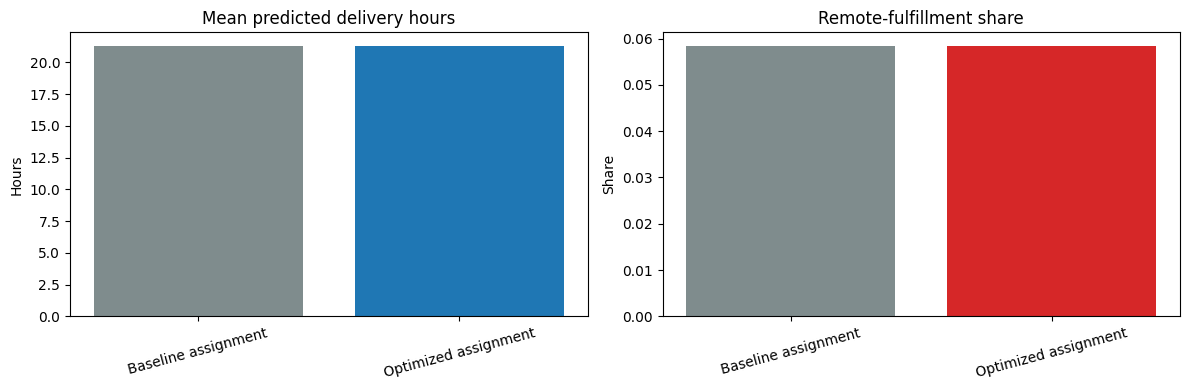

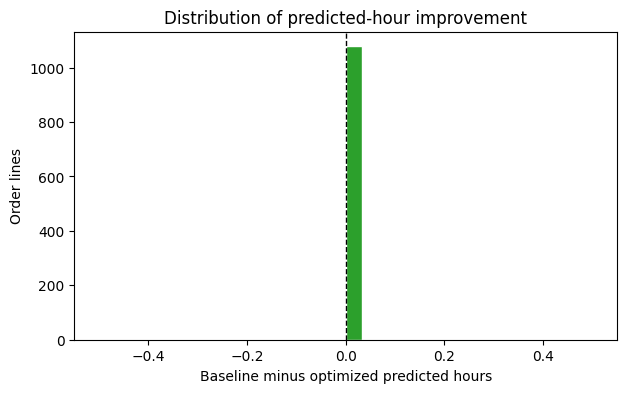

In [8]:
def summarize_outcomes(comparison_df: pd.DataFrame) -> pd.DataFrame:
    baseline_row = {
        "scenario": "Baseline assignment",
        "mean_predicted_hours_to_delivery": comparison_df["baseline_predicted_hours"].mean(),
        "median_predicted_hours_to_delivery": comparison_df["baseline_predicted_hours"].median(),
        "remote_fulfillment_share": comparison_df["baseline_remote_flag"].mean(),
        "average_improvement_in_predicted_hours": 0.0,
    }
    optimized_row = {
        "scenario": "Optimized assignment",
        "mean_predicted_hours_to_delivery": comparison_df["optimized_predicted_hours"].mean(),
        "median_predicted_hours_to_delivery": comparison_df["optimized_predicted_hours"].median(),
        "remote_fulfillment_share": comparison_df["optimized_remote_flag"].mean(),
        "average_improvement_in_predicted_hours": comparison_df["hours_improvement"].mean(),
    }
    return pd.DataFrame([baseline_row, optimized_row])


outcome_summary = summarize_outcomes(comparison_line_level)
change_summary = pd.DataFrame(
    {
        "metric": ["order_lines_compared", "share_reassigned", "average_hours_improvement", "median_hours_improvement"],
        "value": [
            len(comparison_line_level),
            comparison_line_level["reassigned_flag"].mean(),
            comparison_line_level["hours_improvement"].mean(),
            comparison_line_level["hours_improvement"].median(),
        ],
    }
)

baseline_mix = baseline_assignments["baseline_type"].value_counts(normalize=True).rename_axis("baseline_type").reset_index(name="share")

display(outcome_summary)
display(change_summary)
display(baseline_mix)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(outcome_summary["scenario"], outcome_summary["mean_predicted_hours_to_delivery"], color=["#7f8c8d", "#1f77b4"])
axes[0].set_title("Mean predicted delivery hours")
axes[0].set_ylabel("Hours")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(outcome_summary["scenario"], outcome_summary["remote_fulfillment_share"], color=["#7f8c8d", "#d62728"])
axes[1].set_title("Remote-fulfillment share")
axes[1].set_ylabel("Share")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.hist(comparison_line_level["hours_improvement"], bins=30, color="#2ca02c", edgecolor="white")
plt.axvline(comparison_line_level["hours_improvement"].mean(), color="black", linestyle="--", linewidth=1)
plt.title("Distribution of predicted-hour improvement")
plt.xlabel("Baseline minus optimized predicted hours")
plt.ylabel("Order lines")
plt.show()

## 11. Sensitivity analysis on remote penalty

We vary lambda_remote across a small grid to see how strongly the optimization trades off predicted fulfillment time against remote-assignment avoidance.

,lambda_remote,solver_status,objective_value,mean_predicted_hours_to_delivery,median_predicted_hours_to_delivery,remote_fulfillment_share,average_improvement_in_predicted_hours,share_reassigned
0,0,Optimal,22971.230632,21.309119,19.490856,0.058442,0.0,0.000928
1,2,Optimal,23097.230632,21.309119,19.490856,0.058442,0.0,0.000928
2,5,Optimal,23286.230632,21.309119,19.490856,0.058442,0.0,0.000928
3,10,Optimal,23601.230632,21.309119,19.490856,0.058442,0.0,0.000928


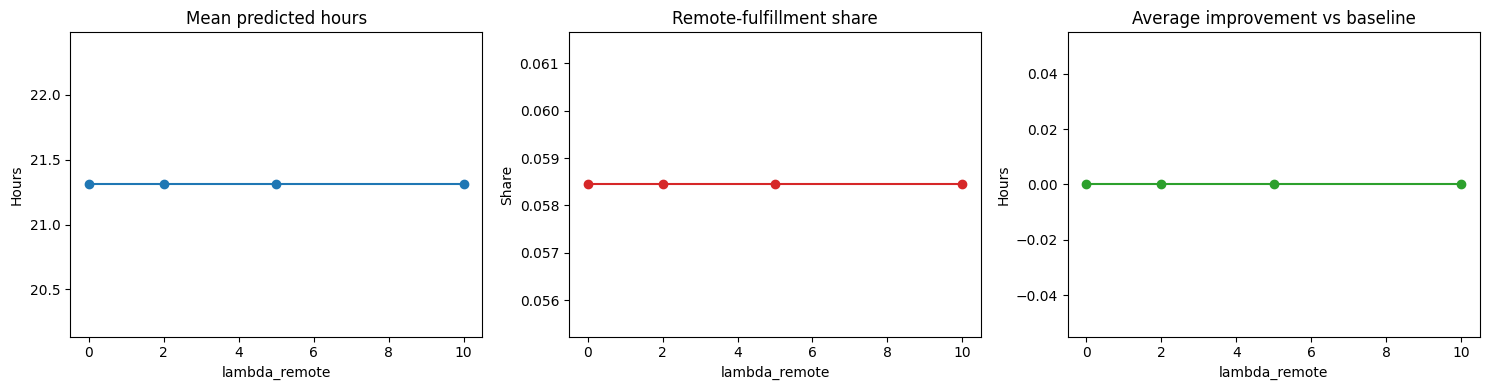

In [9]:
lambda_grid = [0, 2, 5, 10]
sensitivity_rows = []

for lam in lambda_grid:
    model_lam, solution_lam = solve_assignment_model(
        candidate_input=optimization_input,
        lambda_remote=float(lam),
        capacity_proxy=None,
        time_limit_seconds=60,
    )

    optimized_lam = solution_lam[["order_line_id", "candidate_dc", "predicted_hours_to_delivery", "candidate_remote_flag"]].rename(
        columns={
            "candidate_dc": "chosen_candidate_dc",
            "predicted_hours_to_delivery": "optimized_predicted_hours",
            "candidate_remote_flag": "optimized_remote_flag",
        }
    )
    compare_lam = baseline_assignments.merge(optimized_lam, how="inner", on="order_line_id", validate="1:1")
    compare_lam["hours_improvement"] = compare_lam["baseline_predicted_hours"] - compare_lam["optimized_predicted_hours"]
    compare_lam["reassigned_flag"] = (compare_lam["baseline_candidate_dc"] != compare_lam["chosen_candidate_dc"]).astype(int)

    sensitivity_rows.append(
        {
            "lambda_remote": lam,
            "solver_status": pulp.LpStatus[model_lam.status],
            "objective_value": pulp.value(model_lam.objective),
            "mean_predicted_hours_to_delivery": compare_lam["optimized_predicted_hours"].mean(),
            "median_predicted_hours_to_delivery": compare_lam["optimized_predicted_hours"].median(),
            "remote_fulfillment_share": compare_lam["optimized_remote_flag"].mean(),
            "average_improvement_in_predicted_hours": compare_lam["hours_improvement"].mean(),
            "share_reassigned": compare_lam["reassigned_flag"].mean(),
        }
    )

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sensitivity_df["lambda_remote"], sensitivity_df["mean_predicted_hours_to_delivery"], marker="o", color="#1f77b4")
axes[0].set_title("Mean predicted hours")
axes[0].set_xlabel("lambda_remote")
axes[0].set_ylabel("Hours")

axes[1].plot(sensitivity_df["lambda_remote"], sensitivity_df["remote_fulfillment_share"], marker="o", color="#d62728")
axes[1].set_title("Remote-fulfillment share")
axes[1].set_xlabel("lambda_remote")
axes[1].set_ylabel("Share")

axes[2].plot(sensitivity_df["lambda_remote"], sensitivity_df["average_improvement_in_predicted_hours"], marker="o", color="#2ca02c")
axes[2].set_title("Average improvement vs baseline")
axes[2].set_xlabel("lambda_remote")
axes[2].set_ylabel("Hours")

plt.tight_layout()
plt.show()

## 12. Discussion of assumptions and limitations

- Inventory is binary end-of-day availability only. It does not measure exact stock quantity or intra-day depletion.
- Candidate warehouses are restricted to the destination-region network group, so the model is a within-region reassignment exercise rather than a full national network design problem.
- The fulfillment-time input is a predicted proxy from Analysis 3, not an exact operational ETA.
- Delivery coverage is stronger for 1P and some 3P orders with JD-logged delivery records, so the prediction layer may not represent all delivery situations equally well.
- The base model omits true warehouse capacity because throughput is not directly observed in the dataset. A capacity-like constraint could be added only as an explicit proxy assumption.
- The baseline comparison uses a mixed feasible-set baseline: historical dc_ori when feasible, otherwise a simple candidate-set fallback that prefers dc_des. This is more practical for the processed candidate structure, but it is not a perfect reproduction of historical fulfillment policy.
- This is a single-period, short-horizon assignment model for course purposes. It is not a multi-period inventory planning model and not a production fulfillment engine.

## 13. Diagnostic supplement: Why baseline and optimized results look identical

The cells below diagnose whether the near-identical Part C result comes from limited feasible reassignment room, a near-optimal baseline under the current objective, weak candidate-score dispersion, or a logic issue in the simplified setup.

### 13.1 Feasible choice-set size

This section checks whether most order lines have only one feasible warehouse after inventory filtering. If so, the optimizer has very little room to improve the baseline.

,metric,value
0,sample_order_lines,1500.000000
1,mean_total_candidates_per_order_line,7.297333
2,mean_feasible_candidates_per_order_line,2.604000
3,median_feasible_candidates_per_order_line,2.000000
4,share_exactly_1_feasible_candidate,0.106667
5,share_more_than_1_feasible_candidate,0.612000
6,share_zero_feasible_candidate,0.281333


,feasible_candidate_count,order_line_count,share
0,0,422,0.281333
1,1,160,0.106667
2,2,204,0.136000
3,3,189,0.126000
4,4,115,0.076667
5,5,188,0.125333
6,6,183,0.122000
7,7,39,0.026000


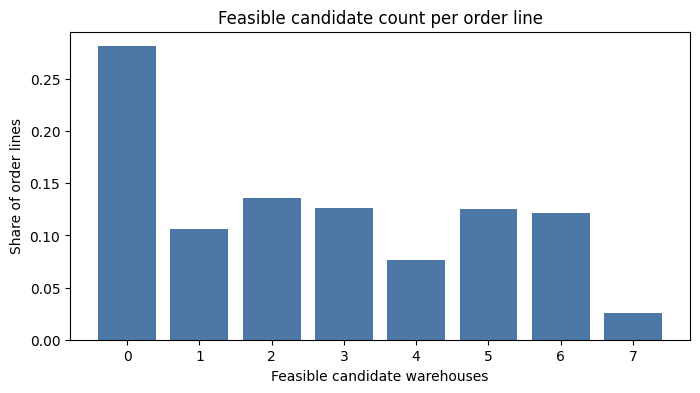

In [10]:
# Diagnose choice-set size on the same sampled order-line pool used by Part C.
diag_candidate_universe = candidate_df.loc[candidate_df["order_line_id"].isin(sample_lines["order_line_id"])].copy()

diag_choice_df = (
    diag_candidate_universe.groupby("order_line_id", as_index=False)
    .agg(
        total_candidate_warehouses=("candidate_dc", "nunique"),
        feasible_candidate_warehouses=("inventory_available", lambda s: int((pd.to_numeric(s, errors="coerce") == 1).sum())),
    )
)

diag_choice_summary = pd.DataFrame(
    {
        "metric": [
            "sample_order_lines",
            "mean_total_candidates_per_order_line",
            "mean_feasible_candidates_per_order_line",
            "median_feasible_candidates_per_order_line",
            "share_exactly_1_feasible_candidate",
            "share_more_than_1_feasible_candidate",
            "share_zero_feasible_candidate",
        ],
        "value": [
            diag_choice_df["order_line_id"].nunique(),
            diag_choice_df["total_candidate_warehouses"].mean(),
            diag_choice_df["feasible_candidate_warehouses"].mean(),
            diag_choice_df["feasible_candidate_warehouses"].median(),
            diag_choice_df["feasible_candidate_warehouses"].eq(1).mean(),
            diag_choice_df["feasible_candidate_warehouses"].gt(1).mean(),
            diag_choice_df["feasible_candidate_warehouses"].eq(0).mean(),
        ],
    }
)

diag_choice_distribution = (
    diag_choice_df["feasible_candidate_warehouses"]
    .value_counts()
    .sort_index()
    .rename_axis("feasible_candidate_count")
    .reset_index(name="order_line_count")
)
diag_choice_distribution["share"] = diag_choice_distribution["order_line_count"] / diag_choice_distribution["order_line_count"].sum()

display(diag_choice_summary)
display(diag_choice_distribution.head(15))

plt.figure(figsize=(8, 4))
plot_df = diag_choice_distribution.loc[diag_choice_distribution["feasible_candidate_count"] <= 10].copy()
plt.bar(plot_df["feasible_candidate_count"].astype(str), plot_df["share"], color="#4c78a8")
plt.title("Feasible candidate count per order line")
plt.xlabel("Feasible candidate warehouses")
plt.ylabel("Share of order lines")
plt.show()

### 13.2 Reassignment activity

This section checks whether the optimizer actually changes assignments and whether any gains are concentrated only among the reassigned subset.

In [11]:
reassigned_only = comparison_line_level.loc[comparison_line_level["reassigned_flag"].eq(1)].copy()

reassignment_summary = pd.DataFrame(
    {
        "metric": [
            "order_lines_compared",
            "reassigned_order_lines",
            "reassignment_rate",
            "average_predicted_improvement_all_order_lines",
            "average_predicted_improvement_reassigned_only",
            "baseline_remote_share_reassigned_only",
            "optimized_remote_share_reassigned_only",
            "remote_share_change_reassigned_only",
        ],
        "value": [
            len(comparison_line_level),
            comparison_line_level["reassigned_flag"].sum(),
            comparison_line_level["reassigned_flag"].mean(),
            comparison_line_level["hours_improvement"].mean(),
            reassigned_only["hours_improvement"].mean() if len(reassigned_only) > 0 else np.nan,
            reassigned_only["baseline_remote_flag"].mean() if len(reassigned_only) > 0 else np.nan,
            reassigned_only["optimized_remote_flag"].mean() if len(reassigned_only) > 0 else np.nan,
            (reassigned_only["optimized_remote_flag"].mean() - reassigned_only["baseline_remote_flag"].mean()) if len(reassigned_only) > 0 else np.nan,
        ],
    }
)

display(reassignment_summary)
display(comparison_line_level.head(10))

,metric,value
0,order_lines_compared,1078.000000
1,reassigned_order_lines,1.000000
2,reassignment_rate,0.000928
3,average_predicted_improvement_all_order_lines,0.000000
4,average_predicted_improvement_reassigned_only,0.000000
5,baseline_remote_share_reassigned_only,1.000000
6,optimized_remote_share_reassigned_only,1.000000
7,remote_share_change_reassigned_only,0.000000


,order_line_id,baseline_candidate_dc,baseline_predicted_hours,baseline_remote_flag,baseline_type,chosen_candidate_dc,optimized_predicted_hours,optimized_remote_flag,hours_improvement,reassigned_flag
0,001411762b_9e452b5aee_0,4.0,19.377280,0,candidate_set_fallback,4.0,19.377280,0,0.0,0
1,001f0aef29_589c2b865b_0,4.0,20.188478,0,candidate_set_fallback,4.0,20.188478,0,0.0,0
2,0020fefefc_904fbf8b97_0,5.0,19.362820,0,candidate_set_fallback,5.0,19.362820,0,0.0,0
3,002149e275_623d0a582a_0,4.0,29.962031,0,candidate_set_fallback,4.0,29.962031,0,0.0,0
4,002e994572_2523d051fd_0,4.0,51.097387,0,candidate_set_fallback,4.0,51.097387,0,0.0,0
5,002e994572_d3e31fdd6e_0,44.0,57.644634,1,candidate_set_fallback,44.0,57.644634,1,0.0,0
6,00341f09cd_b9f08a2a2a_0,5.0,18.653703,0,candidate_set_fallback,5.0,18.653703,0,0.0,0
7,00341f09cd_d7d6bd5e1a_0,5.0,18.464674,0,candidate_set_fallback,5.0,18.464674,0,0.0,0
8,00382eec78_eb3f2d2fd8_0,4.0,18.590455,0,candidate_set_fallback,4.0,18.590455,0,0.0,0
9,003b508948_d47c6ca631_0,9.0,20.801481,0,candidate_set_fallback,9.0,20.801481,0,0.0,0


### 13.3 Candidate-score dispersion

This section checks whether candidate predicted hours are nearly identical within each order line. If they are, the optimizer will not find much improvement even when multiple feasible warehouses exist.

,metric,value
0,mean_within_order_spread,2.714205
1,median_within_order_spread,3.126849
2,mean_within_order_std,1.428320
3,median_within_order_std,1.467428
4,share_spread_le_0_01,0.153989
5,share_spread_le_0_1,0.153989
6,share_spread_le_1_0,0.154917


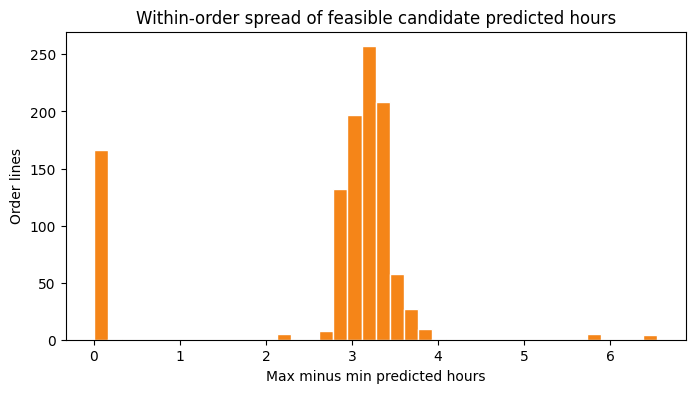

Examples with no meaningful candidate difference


,order_line_id,candidate_dc,dc_des,dc_ori,candidate_remote_flag,predicted_hours_to_delivery
20,002e994572_d3e31fdd6e_0,44.0,4,4,1,57.644634
21,00341f09cd_b9f08a2a2a_0,5.0,5,5,0,18.653703
41,005e73b71a_b118ef50af_0,5.0,5,5,0,17.333107
50,007720ff66_593b9c70a6_0,5.0,5,5,0,19.438453
177,017d1b1c09_6717b7c979_0,4.0,4,4,0,20.103921


Examples with meaningful candidate difference


,order_line_id,candidate_dc,dc_des,dc_ori,candidate_remote_flag,predicted_hours_to_delivery
18,002e994572_2523d051fd_0,4.0,4,4,0,51.097387
19,002e994572_2523d051fd_0,44.0,4,4,1,57.644634
2667,17f2c0e322_c4ea4afceb_0,9.0,9,9,0,50.508064
2662,17f2c0e322_c4ea4afceb_0,25.0,9,9,1,56.981250
2663,17f2c0e322_c4ea4afceb_0,32.0,9,9,1,56.981250
2664,17f2c0e322_c4ea4afceb_0,36.0,9,9,1,56.981250
2665,17f2c0e322_c4ea4afceb_0,50.0,9,9,1,56.981250
2666,17f2c0e322_c4ea4afceb_0,61.0,9,9,1,56.981250
2782,194cc8343f_eb3f2d2fd8_0,5.0,5,5,0,45.581732
2781,194cc8343f_eb3f2d2fd8_0,13.0,5,5,1,51.435809


In [12]:
dispersion_df = (
    optimization_input.groupby("order_line_id", as_index=False)
    .agg(
        feasible_candidate_count=("candidate_dc", "nunique"),
        min_predicted_hours=("predicted_hours_to_delivery", "min"),
        max_predicted_hours=("predicted_hours_to_delivery", "max"),
        std_predicted_hours=("predicted_hours_to_delivery", "std"),
        local_candidate_count=("candidate_remote_flag", lambda s: int((pd.to_numeric(s, errors="coerce") == 0).sum())),
        remote_candidate_count=("candidate_remote_flag", lambda s: int((pd.to_numeric(s, errors="coerce") == 1).sum())),
    )
)

dispersion_df["predicted_hour_spread"] = dispersion_df["max_predicted_hours"] - dispersion_df["min_predicted_hours"]
dispersion_df["std_predicted_hours"] = dispersion_df["std_predicted_hours"].fillna(0.0)

dispersion_summary = pd.DataFrame(
    {
        "metric": [
            "mean_within_order_spread",
            "median_within_order_spread",
            "mean_within_order_std",
            "median_within_order_std",
            "share_spread_le_0_01",
            "share_spread_le_0_1",
            "share_spread_le_1_0",
        ],
        "value": [
            dispersion_df["predicted_hour_spread"].mean(),
            dispersion_df["predicted_hour_spread"].median(),
            dispersion_df["std_predicted_hours"].mean(),
            dispersion_df["std_predicted_hours"].median(),
            dispersion_df["predicted_hour_spread"].le(0.01).mean(),
            dispersion_df["predicted_hour_spread"].le(0.1).mean(),
            dispersion_df["predicted_hour_spread"].le(1.0).mean(),
        ],
    }
)

display(dispersion_summary)

plt.figure(figsize=(8, 4))
plt.hist(dispersion_df["predicted_hour_spread"], bins=40, color="#f58518", edgecolor="white")
plt.title("Within-order spread of feasible candidate predicted hours")
plt.xlabel("Max minus min predicted hours")
plt.ylabel("Order lines")
plt.show()

low_spread_ids = dispersion_df.sort_values(["predicted_hour_spread", "feasible_candidate_count"]).head(5)["order_line_id"]
high_spread_ids = dispersion_df.sort_values(["predicted_hour_spread", "feasible_candidate_count"], ascending=[False, False]).head(5)["order_line_id"]

print("Examples with no meaningful candidate difference")
display(
    optimization_input.loc[optimization_input["order_line_id"].isin(low_spread_ids)]
    .sort_values(["order_line_id", "predicted_hours_to_delivery", "candidate_dc"])
    [["order_line_id", "candidate_dc", "dc_des", "dc_ori", "candidate_remote_flag", "predicted_hours_to_delivery"]]
)

print("Examples with meaningful candidate difference")
display(
    optimization_input.loc[optimization_input["order_line_id"].isin(high_spread_ids)]
    .sort_values(["order_line_id", "predicted_hours_to_delivery", "candidate_dc"])
    [["order_line_id", "candidate_dc", "dc_des", "dc_ori", "candidate_remote_flag", "predicted_hours_to_delivery"]]
)

### 13.4 Baseline-optimality check

This section checks whether the baseline assignment is already the minimum-cost feasible candidate under the same optimization objective.

In [13]:
BASE_LAMBDA_REMOTE = 5.0

baseline_cost_lookup = baseline_assignments.merge(
    optimization_input[["order_line_id", "candidate_dc", "predicted_hours_to_delivery", "candidate_remote_flag"]],
    left_on=["order_line_id", "baseline_candidate_dc"],
    right_on=["order_line_id", "candidate_dc"],
    how="left",
    validate="1:1",
)
baseline_cost_lookup["baseline_objective_cost"] = baseline_cost_lookup["predicted_hours_to_delivery"] + BASE_LAMBDA_REMOTE * baseline_cost_lookup["candidate_remote_flag"]

candidate_objective_df = optimization_input.copy()
candidate_objective_df["objective_cost"] = candidate_objective_df["predicted_hours_to_delivery"] + BASE_LAMBDA_REMOTE * candidate_objective_df["candidate_remote_flag"]
min_cost_df = candidate_objective_df.groupby("order_line_id", as_index=False)["objective_cost"].min().rename(columns={"objective_cost": "min_objective_cost"})

baseline_optimality_df = baseline_cost_lookup.merge(min_cost_df, on="order_line_id", how="left", validate="1:1")
baseline_optimality_df["baseline_already_optimal_flag"] = np.isclose(
    baseline_optimality_df["baseline_objective_cost"],
    baseline_optimality_df["min_objective_cost"],
    atol=1e-8,
)

baseline_optimality_summary = pd.DataFrame(
    {
        "metric": [
            "share_baseline_already_optimal_under_current_objective",
            "share_baseline_not_optimal_under_current_objective",
            "share_optimizer_differs_from_baseline",
        ],
        "value": [
            baseline_optimality_df["baseline_already_optimal_flag"].mean(),
            1 - baseline_optimality_df["baseline_already_optimal_flag"].mean(),
            comparison_line_level["reassigned_flag"].mean(),
        ],
    }
)

display(baseline_optimality_summary)

display(
    baseline_optimality_df.loc[~baseline_optimality_df["baseline_already_optimal_flag"]]
    [["order_line_id", "baseline_candidate_dc", "baseline_type", "baseline_objective_cost", "min_objective_cost"]]
    .head(10)
)

,metric,value
0,share_baseline_already_optimal_under_current_o...,1.000000
1,share_baseline_not_optimal_under_current_objec...,0.000000
2,share_optimizer_differs_from_baseline,0.000928


,order_line_id,baseline_candidate_dc,baseline_type,baseline_objective_cost,min_objective_cost


### 13.5 Sensitivity impact

This section checks whether assignments or aggregate outcomes change at all when lambda_remote changes.

In [14]:
assignment_maps = {}
for lam in lambda_grid:
    model_lam, solution_lam = solve_assignment_model(
        candidate_input=optimization_input,
        lambda_remote=float(lam),
        capacity_proxy=None,
        time_limit_seconds=60,
    )
    assignment_maps[lam] = solution_lam.set_index("order_line_id")["candidate_dc"].astype("string")

lambda_change_rows = []
for lam_prev, lam_next in zip(lambda_grid[:-1], lambda_grid[1:]):
    aligned = pd.DataFrame({
        "prev_dc": assignment_maps[lam_prev],
        "next_dc": assignment_maps[lam_next],
    }).dropna()
    lambda_change_rows.append(
        {
            "from_lambda": lam_prev,
            "to_lambda": lam_next,
            "assignment_change_rate": (aligned["prev_dc"] != aligned["next_dc"]).mean(),
        }
    )

lambda_change_df = pd.DataFrame(lambda_change_rows)
display(sensitivity_df)
display(lambda_change_df)

,lambda_remote,solver_status,objective_value,mean_predicted_hours_to_delivery,median_predicted_hours_to_delivery,remote_fulfillment_share,average_improvement_in_predicted_hours,share_reassigned
0,0,Optimal,22971.230632,21.309119,19.490856,0.058442,0.0,0.000928
1,2,Optimal,23097.230632,21.309119,19.490856,0.058442,0.0,0.000928
2,5,Optimal,23286.230632,21.309119,19.490856,0.058442,0.0,0.000928
3,10,Optimal,23601.230632,21.309119,19.490856,0.058442,0.0,0.000928


,from_lambda,to_lambda,assignment_change_rate
0,0,2,0.0
1,2,5,0.0
2,5,10,0.0


### 13.6 Possible implementation issues and structural explanations

This section checks whether candidate-specific features actually vary enough across warehouses to support meaningful reassignment.

In [15]:
variation_check = (
    optimization_input.groupby("order_line_id", as_index=False)
    .agg(
        feasible_candidate_count=("candidate_dc", "nunique"),
        unique_remote_flags=("candidate_remote_flag", "nunique"),
        unique_predicted_hours=("predicted_hours_to_delivery", lambda s: pd.Series(np.round(s, 6)).nunique()),
    )
)

variation_summary = pd.DataFrame(
    {
        "metric": [
            "share_orders_with_only_one_remote_flag_value",
            "share_orders_with_only_one_unique_predicted_hour",
            "share_orders_with_more_than_one_candidate_but_one_unique_predicted_hour",
            "baseline_historical_if_feasible_share",
            "baseline_destination_dc_fallback_share",
            "baseline_candidate_set_fallback_share",
        ],
        "value": [
            variation_check["unique_remote_flags"].eq(1).mean(),
            variation_check["unique_predicted_hours"].eq(1).mean(),
            ((variation_check["feasible_candidate_count"] > 1) & (variation_check["unique_predicted_hours"] == 1)).mean(),
            baseline_assignments["baseline_type"].eq("historical_if_feasible").mean(),
            baseline_assignments["baseline_type"].eq("destination_dc_fallback").mean(),
            baseline_assignments["baseline_type"].eq("candidate_set_fallback").mean(),
        ],
    }
)

display(variation_summary)
display(variation_check.head(10))

,metric,value
0,share_orders_with_only_one_remote_flag_value,0.153989
1,share_orders_with_only_one_unique_predicted_hour,0.153989
2,share_orders_with_more_than_one_candidate_but_...,0.005566
3,baseline_historical_if_feasible_share,0.000000
4,baseline_destination_dc_fallback_share,0.000000
5,baseline_candidate_set_fallback_share,1.000000


,order_line_id,feasible_candidate_count,unique_remote_flags,unique_predicted_hours
0,001411762b_9e452b5aee_0,5,2,2
1,001f0aef29_589c2b865b_0,5,2,2
2,0020fefefc_904fbf8b97_0,2,2,2
3,002149e275_623d0a582a_0,6,2,2
4,002e994572_2523d051fd_0,2,2,2
5,002e994572_d3e31fdd6e_0,1,1,1
6,00341f09cd_b9f08a2a2a_0,1,1,1
7,00341f09cd_d7d6bd5e1a_0,2,2,2
8,00382eec78_eb3f2d2fd8_0,3,2,2
9,003b508948_d47c6ca631_0,6,2,2


### 13.7 Honest interpretation for the report

Use the diagnostic tables above to decide which explanation is most supported:

- If most order lines have exactly one feasible candidate, the optimization has limited room to improve anything.
- If many order lines have multiple feasible candidates but almost zero score spread, the candidate scoring is too coarse to reveal improvement.
- If baseline is already optimal for most order lines under the same objective, then the near-identical result is a valid empirical finding rather than a model failure.
- If many order lines have multiple feasible candidates, meaningful score spread, and a non-optimal baseline, but the optimizer still does not move, then the result may point to an implementation issue worth fixing.